<a href="https://colab.research.google.com/github/nadirbellati-cmd/DEEP-LEARNING/blob/main/projet_deep_learning_colab_Nadir_Bellati.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet Deep Learning — PyTorch (Google Colab)

Ce notebook regroupe deux exercices pédagogiques :

1. **Partie A** — Reconnaissance de chiffres manuscrits (MNIST, MLP)
2. **Partie B** — Analyse de sentiment (IMDb, Embedding + moyenne)

**Colab :** Runtime → Modifier le type d'exécution → **GPU** (recommandé pour la partie A).

## Installation (Colab)

PyTorch et torchvision sont déjà installés sur Colab. On met à jour `datasets` (Hugging Face) pour l'IMDb. **Redémarrez la session** après cette cellule si vous aviez déjà une erreur.

In [ ]:
!pip install -q -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.6 MB/s eta 0:00:00


## Imports communs

In [ ]:
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import datasets, transforms
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


---
# Partie A — MNIST (chiffres manuscrits)

Architecture : **MLP** `784 → 256 → 128 → 10`  
Loss / optimiseur : **CrossEntropyLoss** + **Adam**

> Aucun softmax explicite avant `CrossEntropyLoss` (il est intégré à la loss).

### A.1 — Chargement MNIST

In [ ]:
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform_mnist)
test_mnist = datasets.MNIST(root="./data", train=False, download=True, transform=transform_mnist)

batch_size_mnist = 64
train_loader_mnist = DataLoader(train_mnist, batch_size=batch_size_mnist, shuffle=True)
test_loader_mnist = DataLoader(test_mnist, batch_size=batch_size_mnist, shuffle=False)

print(f"Train : {len(train_mnist)} | Test : {len(test_mnist)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


Train : 60000 | Test : 10000


### A.2 — Visualisation

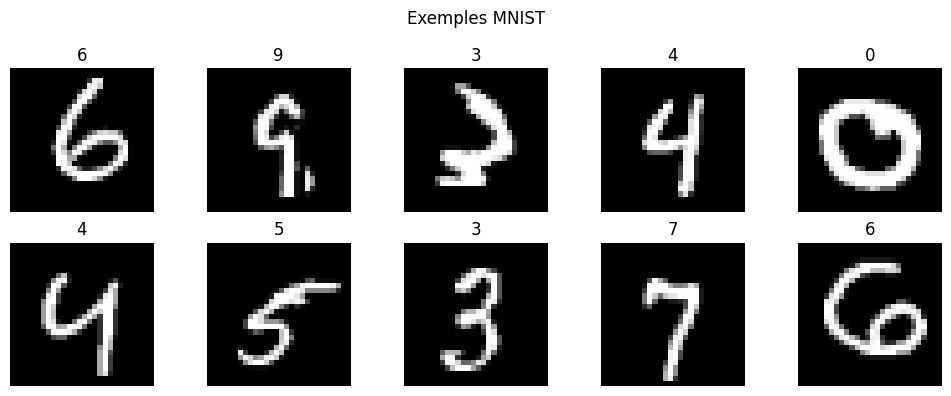

In [ ]:
images, labels = next(iter(train_loader_mnist))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(str(labels[i].item()))
    ax.axis("off")
plt.suptitle("Exemples MNIST")
plt.tight_layout()
plt.show()

### A.3 — Modèle MLP (`x.view` pour aplatir)

In [ ]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


model_mnist = MNISTMLP().to(device)
criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(model_mnist.parameters(), lr=1e-3)
print(model_mnist)

MNISTMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


### A.4 — Accuracy et entraînement

In [ ]:
def mnist_accuracy(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total


num_epochs_mnist = 10
history_mnist = {"train_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_mnist + 1):
    model_mnist.train()
    running_loss = 0.0
    for x, y in train_loader_mnist:
        x, y = x.to(device), y.to(device)
        optimizer_mnist.zero_grad()
        logits = model_mnist(x)
        loss = criterion_mnist(logits, y)
        loss.backward()
        optimizer_mnist.step()
        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(train_mnist)
    test_acc = mnist_accuracy(test_loader_mnist, model_mnist)
    history_mnist["train_loss"].append(epoch_loss)
    history_mnist["test_acc"].append(test_acc)
    print(f"Époque {epoch:2d} | loss train : {epoch_loss:.4f} | accuracy test : {test_acc:.4f}")

Époque  1 | loss train : 0.2256 | accuracy test : 0.9662
Époque  2 | loss train : 0.0937 | accuracy test : 0.9677
Époque  3 | loss train : 0.0653 | accuracy test : 0.9768
Époque  4 | loss train : 0.0475 | accuracy test : 0.9779
Époque  5 | loss train : 0.0408 | accuracy test : 0.9773
Époque  6 | loss train : 0.0328 | accuracy test : 0.9776
Époque  7 | loss train : 0.0270 | accuracy test : 0.9681
Époque  8 | loss train : 0.0249 | accuracy test : 0.9776
Époque  9 | loss train : 0.0207 | accuracy test : 0.9800
Époque 10 | loss train : 0.0222 | accuracy test : 0.9782


### A.5 — Courbes et images mal classées

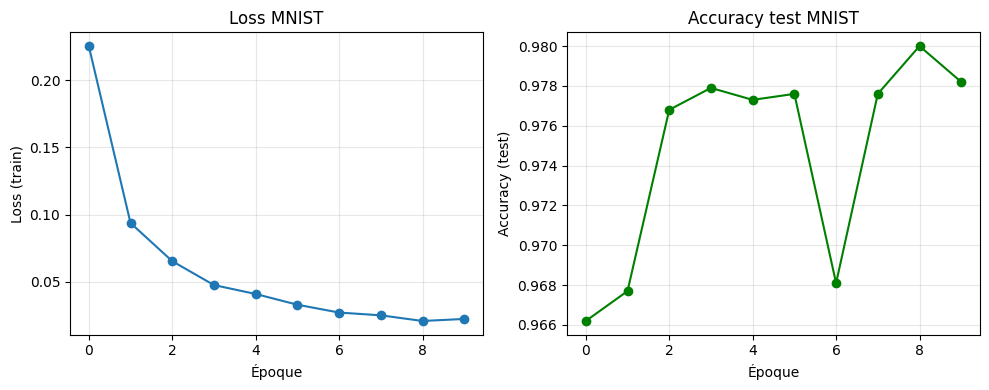

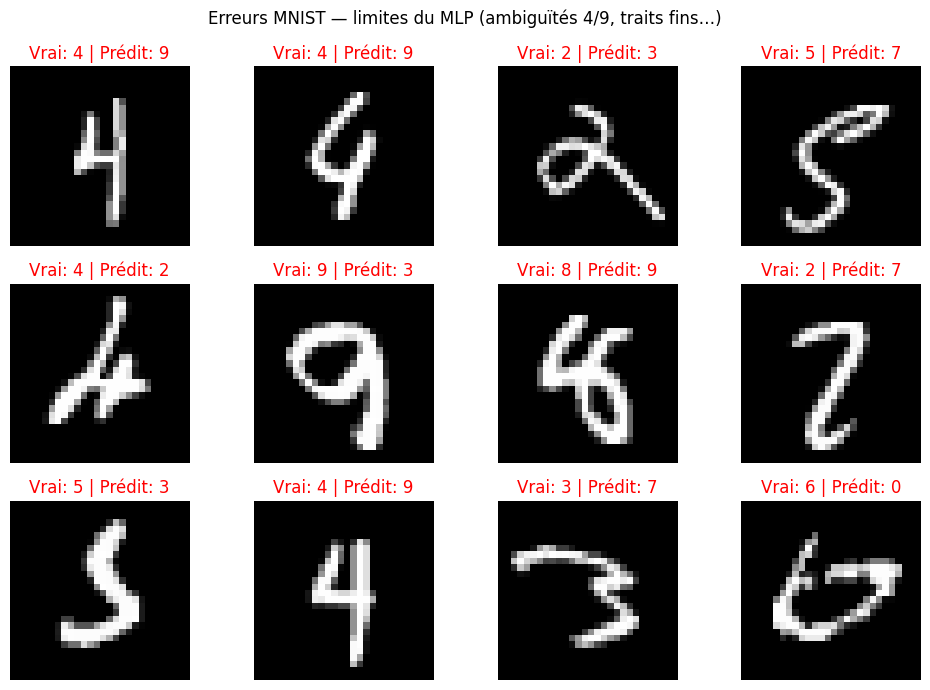

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(history_mnist["train_loss"], marker="o")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss (train)")
ax1.set_title("Loss MNIST")
ax1.grid(True, alpha=0.3)
ax2.plot(history_mnist["test_acc"], marker="o", color="green")
ax2.set_xlabel("Époque")
ax2.set_ylabel("Accuracy (test)")
ax2.set_title("Accuracy test MNIST")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

model_mnist.eval()
err_imgs, err_true, err_pred = [], [], []
with torch.no_grad():
    for x, y in test_loader_mnist:
        x, y = x.to(device), y.to(device)
        preds = model_mnist(x).argmax(dim=1)
        wrong = preds != y
        for i in range(x.size(0)):
            if wrong[i] and len(err_imgs) < 12:
                err_imgs.append(x[i].cpu())
                err_true.append(y[i].item())
                err_pred.append(preds[i].item())
        if len(err_imgs) >= 12:
            break

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for ax, img, t, p in zip(axes.flat, err_imgs, err_true, err_pred):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Vrai: {t} | Prédit: {p}", color="red")
    ax.axis("off")
plt.suptitle("Erreurs MNIST — limites du MLP (ambiguïtés 4/9, traits fins…)")
plt.tight_layout()
plt.show()

### A.6 — (Extension) CNN — décommenter pour comparer

---
# Partie B — Analyse de sentiment

Pipeline : tokenisation → vocabulaire → padding → **Embedding** → **moyenne** → **Linear**  
Loss : **BCEWithLogitsLoss** + **Adam** (sigmoid uniquement à l'inférence / seuil)

### B.1 — Données IMDb

In [ ]:
raw_imdb = load_dataset("stanfordnlp/imdb")
train_texts = raw_imdb["train"]["text"]
train_labels_sent = raw_imdb["train"]["label"]
test_texts = raw_imdb["test"]["text"]
test_labels_sent = raw_imdb["test"]["label"]

# Sous-échantillon (Colab rapide) — supprimez ces 4 lignes pour l'IMDb complet
MAX_TRAIN, MAX_TEST = 5000, 1000
train_texts = train_texts[:MAX_TRAIN]
train_labels_sent = train_labels_sent[:MAX_TRAIN]
test_texts = test_texts[:MAX_TEST]
test_labels_sent = test_labels_sent[:MAX_TEST]

print(f"Train : {len(train_texts)} | Test : {len(test_texts)}")
print("Exemple :", train_texts[0][:100], "...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train : 5000 | Test : 1000
Exemple : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w ...


### B.2 — Tokenisation, vocabulaire, padding

In [ ]:
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"


def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    return text.split()


def build_vocab(texts, min_freq=2):
    counter = Counter()
    for t in texts:
        counter.update(simple_tokenize(t))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab


def text_to_indices(text, vocab):
    return [vocab.get(w, vocab[UNK_TOKEN]) for w in simple_tokenize(text)]


vocab = build_vocab(train_texts, min_freq=2)
vocab_size = len(vocab)
print(f"Vocabulaire : {vocab_size} mots")

Vocabulaire : 22746 mots


In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        seq = torch.tensor(text_to_indices(self.texts[i], self.vocab), dtype=torch.long)
        label = torch.tensor(float(self.labels[i]), dtype=torch.float32)
        return seq, label


def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded, torch.stack(labels), lengths


train_ds_sent = SentimentDataset(train_texts, train_labels_sent, vocab)
test_ds_sent = SentimentDataset(test_texts, test_labels_sent, vocab)
batch_size_sent = 32
train_loader_sent = DataLoader(train_ds_sent, batch_size=batch_size_sent, shuffle=True, collate_fn=collate_fn)
test_loader_sent = DataLoader(test_ds_sent, batch_size=batch_size_sent, shuffle=False, collate_fn=collate_fn)

### B.3 — Modèle (moyenne des embeddings)

In [ ]:
class SentimentAvgModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.fc = nn.Linear(emb_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        mean_emb = (emb * mask).sum(dim=1) / lengths.clamp(min=1).unsqueeze(1).float()
        return self.fc(mean_emb).squeeze(1)


model_sent = SentimentAvgModel(vocab_size, emb_dim=128).to(device)
criterion_sent = nn.BCEWithLogitsLoss()
optimizer_sent = optim.Adam(model_sent.parameters(), lr=1e-3)
print(model_sent)

SentimentAvgModel(
  (embedding): Embedding(22746, 128, padding_idx=0)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


### B.4 — Métriques et entraînement

In [ ]:
def evaluate_sentiment(loader, model, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for x, y, lengths in loader:
            x, y = x.to(device), y.to(device)
            lengths = lengths.to(device)
            logits = model(x, lengths)
            total_loss += criterion_sent(logits, y).item() * x.size(0)
            n += x.size(0)
            probs = torch.sigmoid(logits)
            all_preds.extend((probs >= threshold).long().cpu().numpy())
            all_labels.extend(y.long().cpu().numpy())
    return {
        "loss": total_loss / n,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
    }


num_epochs_sent = 5
for epoch in range(1, num_epochs_sent + 1):
    model_sent.train()
    running_loss, n = 0.0, 0
    for x, y, lengths in train_loader_sent:
        x, y = x.to(device), y.to(device)
        lengths = lengths.to(device)
        optimizer_sent.zero_grad()
        logits = model_sent(x, lengths)
        loss = criterion_sent(logits, y)
        loss.backward()
        optimizer_sent.step()
        running_loss += loss.item() * x.size(0)
        n += x.size(0)
    m = evaluate_sentiment(test_loader_sent, model_sent)
    print(
        f"Époque {epoch} | loss train {running_loss/n:.4f} | loss test {m['loss']:.4f} | "
        f"acc {m['accuracy']:.4f} | P {m['precision']:.4f} | R {m['recall']:.4f} | F1 {m['f1']:.4f}"
    )

Époque 1 | loss train 0.2940 | loss test 0.0586 | acc 1.0000 | P 0.0000 | R 0.0000 | F1 0.0000
Époque 2 | loss train 0.0278 | loss test 0.0108 | acc 1.0000 | P 0.0000 | R 0.0000 | F1 0.0000
Époque 3 | loss train 0.0077 | loss test 0.0043 | acc 1.0000 | P 0.0000 | R 0.0000 | F1 0.0000
Époque 4 | loss train 0.0036 | loss test 0.0023 | acc 1.0000 | P 0.0000 | R 0.0000 | F1 0.0000
Époque 5 | loss train 0.0021 | loss test 0.0014 | acc 1.0000 | P 0.0000 | R 0.0000 | F1 0.0000


### B.5 — Prédiction sur un texte

In [ ]:
def predict_sentiment(text, model, vocab, threshold=0.5):
    model.eval()
    indices = torch.tensor([text_to_indices(text, vocab)], dtype=torch.long).to(device)
    lengths = torch.tensor([indices.size(1)]).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(indices, lengths)).item()
    return {"label": "positif" if prob >= threshold else "négatif", "prob_positive": prob}


for ex in [
    "This movie was absolutely wonderful and inspiring!",
    "Terrible waste of time, I hated every minute.",
]:
    print(ex)
    print(predict_sentiment(ex, model_sent, vocab))
    print()

This movie was absolutely wonderful and inspiring!
{'label': 'négatif', 'prob_positive': 0.0009098479640670121}

Terrible waste of time, I hated every minute.
{'label': 'négatif', 'prob_positive': 0.0020063919946551323}

